# Recovery Ablation Runbook

This notebook runs the full recovery ablation matrix and summarizes outputs.

It wraps:
- `scripts/recovery_ablation.py`
- output CSVs under `runs/experiments/recovery_ablation/metrics/`


In [1]:
from pathlib import Path
import os
import sys
import subprocess
import importlib.util

import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)

    repo_candidates = [
        "/content/drive/MyDrive/Forward-Risk-Manager",
        "/content/drive/MyDrive/forward-risk-manager",
        "/content/Forward-Risk-Manager",
    ]
    existing = [p for p in repo_candidates if Path(p).exists()]

    if existing:
        ROOT = Path(existing[0]).resolve()
    else:
        drive_root = Path("/content/drive/MyDrive")
        fuzzy = sorted(
            (p for p in drive_root.glob("*Forward*Risk*Manager*") if p.is_dir()),
            key=lambda x: str(x),
        ) if drive_root.exists() else []
        if not fuzzy:
            raise FileNotFoundError(
                "Repo not found under /content/drive/MyDrive. "
                "Place the repo in Drive or set ROOT manually in this cell."
            )
        ROOT = fuzzy[0].resolve()
        print("Using discovered repo dir:", ROOT)
else:
    start = Path.cwd().resolve()
    ROOT = None
    for cand in [start, *start.parents]:
        if (cand / "scripts").exists() and (cand / "configs").exists():
            ROOT = cand
            break
    if ROOT is None:
        raise RuntimeError(
            "Could not find repo root (expected scripts/ and configs/). "
            "Start notebook from repo root or set ROOT manually in this cell."
        )

os.chdir(ROOT)

PYTHON = str(ROOT / ".venv" / "bin" / "python")
if not Path(PYTHON).exists():
    PYTHON = sys.executable

print("ROOT:", ROOT)
print("PYTHON:", PYTHON)
print("CWD:", Path.cwd())


Mounted at /content/drive
ROOT: /content/drive/MyDrive/Forward-Risk-Manager
PYTHON: /usr/bin/python3
CWD: /content/drive/MyDrive/Forward-Risk-Manager


In [2]:
import tomllib

# Set to a specific config path to pin reruns. Leave as None to auto-pick.
BASE_CONFIG_OVERRIDE = ROOT / "configs" / "default.toml"

BASE_CONFIG_CANDIDATES = [
    ROOT / "configs" / "default.toml",  # prefer ablation-updated defaults
    ROOT / "configs" / "train_long_constituents.toml",
]

DATA_CANDIDATES = [
    {
        "name": "processed_long",
        "prices": ROOT / "data" / "processed_long" / "prices.csv",
        "constituents": ROOT / "data" / "processed_long" / "constituents.csv",
        "fundamentals": ROOT / "data" / "raw_merged" / "fundamentals.csv",  # optional fallback
    },
    {
        "name": "raw_merged",
        "prices": ROOT / "data" / "raw_merged" / "prices.csv",
        "constituents": ROOT / "data" / "raw_merged" / "constituents.csv",
        "fundamentals": ROOT / "data" / "raw_merged" / "fundamentals.csv",
    },
    {
        "name": "processed",
        "prices": ROOT / "data" / "processed" / "prices.csv",
        "constituents": ROOT / "data" / "processed" / "constituents.csv",
        "fundamentals": ROOT / "data" / "processed" / "fundamentals.csv",
    },
]

def _pick_base_config():
    if BASE_CONFIG_OVERRIDE is not None:
        override = Path(BASE_CONFIG_OVERRIDE)
        if override.exists():
            return override
        raise FileNotFoundError(f"BASE_CONFIG_OVERRIDE not found: {override}")
    for c in BASE_CONFIG_CANDIDATES:
        if c.exists():
            return c
    raise FileNotFoundError("No base config found under configs/.")

def _pick_data_bundle():
    for d in DATA_CANDIDATES:
        if d["prices"].exists() and d["constituents"].exists():
            return d
    raise FileNotFoundError(
        "Could not find prices/constituents in data/processed_long, data/raw_merged, or data/processed."
    )

def _rel(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)

def _toml_value(v):
    if isinstance(v, bool):
        return "true" if v else "false"
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        return repr(float(v))
    if isinstance(v, str):
        esc = v.replace("\\", "\\\\").replace('"', '\\"')
        return f'"{esc}"'
    if isinstance(v, list):
        return "[" + ", ".join(_toml_value(x) for x in v) + "]"
    raise TypeError(f"Unsupported TOML value type: {type(v)}")

def _write_section(lines, name, data):
    lines.append(f"[{name}]")
    for k, v in data.items():
        if isinstance(v, dict):
            continue
        lines.append(f"{k} = {_toml_value(v)}")
    lines.append("")
    for k, v in data.items():
        if isinstance(v, dict):
            _write_section(lines, f"{name}.{k}", v)

base_config = _pick_base_config()
with base_config.open("rb") as f:
    cfg = tomllib.load(f)

data_bundle = _pick_data_bundle()
cfg.setdefault("build_graphs", {})
cfg.setdefault("train", {})
cfg.setdefault("benchmark", {})

cfg["build_graphs"]["prices"] = _rel(data_bundle["prices"])
cfg["build_graphs"]["constituents"] = _rel(data_bundle["constituents"])

fund_path = data_bundle.get("fundamentals")
if fund_path is not None and Path(fund_path).exists():
    cfg["build_graphs"]["fundamentals"] = _rel(Path(fund_path))
else:
    # keep fundamentals optional to avoid build failures when absent
    cfg["build_graphs"]["fundamentals"] = ""

runtime_cfg_dir = ROOT / "runs" / "experiments" / "recovery_ablation" / "runtime"
runtime_cfg_dir.mkdir(parents=True, exist_ok=True)
RUNTIME_CONFIG = runtime_cfg_dir / "recovery_ablation_runtime.toml"

cfg["benchmark"]["baseline_out_csv"] = _rel(ROOT / "runs" / "experiments" / "recovery_ablation" / "metrics" / "benchmark_baseline.csv")

lines = []
for sec in ["build_graphs", "train", "benchmark"]:
    _write_section(lines, sec, cfg.get(sec, {}))
RUNTIME_CONFIG.write_text("\n".join(lines))

CONFIG = RUNTIME_CONFIG
RUN_DIR = ROOT / "runs" / "experiments" / "recovery_ablation"
METRICS_DIR = RUN_DIR / "metrics"
PLAN_CSV = METRICS_DIR / "recovery_ablation_plan.csv"
ABLATION_CSV = METRICS_DIR / "recovery_ablation.csv"
SUMMARY_CSV = METRICS_DIR / "recovery_ablation_summary.csv"

print("Base config:", base_config)
print("Data bundle:", data_bundle["name"])
print("Using prices:", cfg["build_graphs"]["prices"])
print("Using constituents:", cfg["build_graphs"]["constituents"])
print("Using fundamentals:", cfg["build_graphs"].get("fundamentals", ""))
print("FF knobs:", {
    "neg_mode": cfg["train"].get("neg_mode"),
    "ff_neg_mix": cfg["train"].get("ff_neg_mix"),
    "ff_neg_mix_weights": cfg["train"].get("ff_neg_mix_weights"),
    "ff_curriculum_epochs": cfg["train"].get("ff_curriculum_epochs"),
    "ff_rank_aux_weight": cfg["train"].get("ff_rank_aux_weight"),
    "ff_concat_posneg": cfg["train"].get("ff_concat_posneg"),
    "ff_layer_cache": cfg["train"].get("ff_layer_cache"),
    "torch_compile": cfg["train"].get("torch_compile"),
})
print("Benchmark knobs:", {
    "timing_warmup_epochs": cfg["benchmark"].get("timing_warmup_epochs"),
    "baseline_out_csv": cfg["benchmark"].get("baseline_out_csv"),
    "econ_regime_thresholding_enabled": cfg["benchmark"].get("econ_regime_thresholding_enabled"),
    "econ_regime_threshold_window": cfg["benchmark"].get("econ_regime_threshold_window"),
    "econ_regime_threshold_quantile": cfg["benchmark"].get("econ_regime_threshold_quantile"),
})
print("Runtime CONFIG:", CONFIG)


Base config: /content/drive/MyDrive/Forward-Risk-Manager/configs/default.toml
Data bundle: processed_long
Using prices: data/processed_long/prices.csv
Using constituents: data/processed_long/constituents.csv
Using fundamentals: data/raw_merged/fundamentals.csv
Runtime CONFIG: /content/drive/MyDrive/Forward-Risk-Manager/runs/experiments/recovery_ablation/runtime/recovery_ablation_runtime.toml


## Dependencies (Colab-safe)

Run this once before full execution. If packages are installed now, restart runtime/session and rerun from the top.

This runbook prefers `data/processed_long/*` when available.


In [3]:
required = [
    "torch",
    "torch_geometric",
    "pandas",
    "numpy",
    "matplotlib",
    "tqdm",
]
missing = [m for m in required if importlib.util.find_spec(m) is None]

if missing:
    print("Missing packages:", missing)
    cmd = [PYTHON, "-m", "pip", "install", "-r", str(ROOT / "requirements.txt")]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
    print("\nInstall complete.")
    print("If running in Colab, restart session/runtime, then rerun notebook from top.")
else:
    print("All required packages already available.")


Missing packages: ['torch_geometric']
Running: /usr/bin/python3 -m pip install -r /content/drive/MyDrive/Forward-Risk-Manager/requirements.txt

Install complete.
If running in Colab, restart session/runtime, then rerun notebook from top.


## Optional: Dry Run (plan only)


In [4]:
RUN_DRY_RUN = False

if RUN_DRY_RUN:
    cmd = [
        PYTHON,
        "scripts/recovery_ablation.py",
        "--config", str(CONFIG),
        "--dry-run",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("Dry-run disabled. Set RUN_DRY_RUN=True to execute.")


Dry-run disabled. Set RUN_DRY_RUN=True to execute.


## Full Run

This executes selected ablations and can take a while.

The script prints a live `tqdm` progress bar with ETA (`RecoveryAblation ... [elapsed<remaining]`).

Quick rerun presets (set in next cell):
- Full matrix: `RUN_FAMILIES = ""`
- Risk-head sweep only: `RUN_FAMILIES = "risk_head"`
- Fast smoke rerun: set `BENCHMARK_EPOCHS = 3` and `MAX_EXPERIMENTS > 0`


In [5]:
# Colab/T4-friendly defaults and rerun controls
CONTINUE_ON_ERROR = True
BENCHMARK_BATCH_SIZE = 16  # lower if you still hit OOM (e.g., 8)
RUN_FAMILIES = ""  # e.g. "risk_head"
RUN_MODES = "ff_e2e,ff_layerwise,backprop"
BENCHMARK_EPOCHS = 0  # 0 keeps config value
MAX_EXPERIMENTS = 0  # 0 runs all selected experiments
EXTRA_ARGS = []  # Any additional raw args

cmd = [
    PYTHON,
    "scripts/recovery_ablation.py",
    "--config", str(CONFIG),
    "--benchmark-batch-size", str(BENCHMARK_BATCH_SIZE),
    "--modes", RUN_MODES,
]
if BENCHMARK_EPOCHS > 0:
    cmd.extend(["--benchmark-epochs", str(BENCHMARK_EPOCHS)])
if RUN_FAMILIES.strip():
    cmd.extend(["--families", RUN_FAMILIES.strip()])
if MAX_EXPERIMENTS > 0:
    cmd.extend(["--max-experiments", str(MAX_EXPERIMENTS)])
if CONTINUE_ON_ERROR:
    cmd.append("--continue-on-error")
cmd.extend(EXTRA_ARGS)

env = os.environ.copy()
# Helps reduce CUDA fragmentation-related OOM in long runs.
env.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
print("Running:", " ".join(cmd))
print("PYTORCH_CUDA_ALLOC_CONF=", env.get("PYTORCH_CUDA_ALLOC_CONF"))
# Stream output live so progress bar + ETA are visible while running.
proc = subprocess.run(cmd, cwd=str(ROOT), env=env)
print("\nReturn code:", proc.returncode)
if proc.returncode != 0:
    raise RuntimeError("recovery_ablation.py failed. Check logs above for the failing ablation.")


Running: /usr/bin/python3 scripts/recovery_ablation.py --config /content/drive/MyDrive/Forward-Risk-Manager/runs/experiments/recovery_ablation/runtime/recovery_ablation_runtime.toml --benchmark-batch-size 16 --modes ff_e2e,ff_layerwise,backprop --benchmark-epochs 3 --families risk_head --continue-on-error
PYTORCH_CUDA_ALLOC_CONF= expandable_segments:True

Return code: 0


## Load Outputs


In [6]:
BASELINE_CSV = METRICS_DIR / "benchmark_baseline.csv"

for p in [PLAN_CSV, ABLATION_CSV, SUMMARY_CSV, BASELINE_CSV]:
    print(p, "exists=" + str(p.exists()))

plan_df = pd.read_csv(PLAN_CSV) if PLAN_CSV.exists() else pd.DataFrame()
abl_df = pd.read_csv(ABLATION_CSV) if ABLATION_CSV.exists() else pd.DataFrame()
sum_df = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()

print("plan rows:", len(plan_df))
print("ablation rows:", len(abl_df))
print("summary rows:", len(sum_df))


/content/drive/MyDrive/Forward-Risk-Manager/runs/experiments/recovery_ablation/metrics/recovery_ablation_plan.csv exists=True
/content/drive/MyDrive/Forward-Risk-Manager/runs/experiments/recovery_ablation/metrics/recovery_ablation.csv exists=True
/content/drive/MyDrive/Forward-Risk-Manager/runs/experiments/recovery_ablation/metrics/recovery_ablation_summary.csv exists=True
plan rows: 5
ablation rows: 15
summary rows: 2


In [7]:
if not abl_df.empty:
    cols = [
        "ablation_id",
        "ablation_family",
        "mode",
        "row_type",
        "eval_sep",
        "econ_sharpe_uplift",
        "econ_ann_return_uplift",
        "delta_eval_sep_vs_baseline",
        "delta_econ_sharpe_uplift_vs_baseline",
        "time_neg_gen_s",
        "time_hallucinate_s",
        "time_forward_pos_s",
        "time_forward_neg_s",
        "time_loss_terms_s",
        "time_optimizer_s",
        "time_econ_eval_s",
        "graphs_per_s",
        "avg_epoch_s",
        "econ_regime_threshold_window",
        "econ_regime_threshold_quantile",
        "status",
    ]
    cols = [c for c in cols if c in abl_df.columns]
    display(abl_df[cols].head(30))
else:
    print("No ablation rows found yet.")


,ablation_id,ablation_family,mode,row_type,eval_sep,econ_sharpe_uplift,econ_ann_return_uplift,delta_eval_sep_vs_baseline,delta_econ_sharpe_uplift_vs_baseline,status
0,baseline_updated,baseline,ff_e2e,aggregate,6.760634,0.958215,0.018112,0.000000,0.000000,ok
1,baseline_updated,baseline,ff_layerwise,aggregate,2.235350,-0.713313,-0.253968,0.000000,0.000000,ok
2,baseline_updated,baseline,backprop,aggregate,14.183036,0.481797,-0.067227,0.000000,0.000000,ok
3,risk_head_off,risk_head,ff_e2e,aggregate,7.141854,-0.182601,-0.185359,0.381220,-1.140815,ok
4,risk_head_off,risk_head,ff_layerwise,aggregate,2.064535,-0.781576,-0.251158,-0.170816,-0.068263,ok
5,risk_head_off,risk_head,backprop,aggregate,14.444702,0.021167,-0.128737,0.261667,-0.460630,ok
6,risk_head_weight_low,risk_head,ff_e2e,aggregate,6.760453,0.958215,0.018112,-0.000181,0.000000,ok
7,risk_head_weight_low,risk_head,ff_layerwise,aggregate,2.235400,-0.713313,-0.253968,0.000050,0.000000,ok
8,risk_head_weight_low,risk_head,backprop,aggregate,14.180812,0.493373,-0.065674,-0.002224,0.011576,ok
9,risk_head_weight_lower,risk_head,ff_e2e,aggregate,6.780601,1.041995,0.031896,0.019966,0.083781,ok


In [8]:
if not abl_df.empty:
    view = abl_df.copy()
    if "row_type" in view.columns:
        view = view[view["row_type"].fillna("aggregate") != "fold"]

    for col in ["eval_sep", "econ_sharpe_uplift", "econ_ann_return_uplift"]:
        if col in view.columns:
            view[col] = pd.to_numeric(view[col], errors="coerce")

    sort_cols = [c for c in ["econ_sharpe_uplift", "eval_sep", "graphs_per_s"] if c in view.columns]
    if sort_cols:
        view = view.sort_values(sort_cols, ascending=[False] * len(sort_cols))

    print("Top rows by economics, separation, then throughput:")
    display(view.head(20))

    if {"ablation_family", "ablation_id", "mode", "eval_sep", "econ_sharpe_uplift", "econ_ann_return_uplift"}.issubset(view.columns):
        risk_view = view[view["ablation_family"] == "risk_head"].copy()
        if not risk_view.empty:
            keep = [
                "ablation_id",
                "mode",
                "eval_sep",
                "delta_eval_sep_vs_baseline",
                "econ_sharpe_uplift",
                "delta_econ_sharpe_uplift_vs_baseline",
                "econ_ann_return_uplift",
                "delta_econ_ann_return_uplift_vs_baseline",
                "status",
            ]
            keep = [k for k in keep if k in risk_view.columns]
            risk_view = risk_view.sort_values(["mode", "econ_sharpe_uplift"], ascending=[True, False])
            print("\nRisk-head sweep snapshot:")
            display(risk_view[keep])
else:
    print("No aggregate rows to rank yet.")


Top rows by economics then separation:


,ablation_description,ablation_family,ablation_id,avg_epoch_s,avg_epoch_s_std,delta_econ_ann_return_uplift_vs_baseline,delta_econ_sharpe_uplift_vs_baseline,delta_eval_sep_vs_baseline,econ_ann_return_uplift,econ_ann_return_uplift_std,...,primary_eval_metric_robust_std,primary_eval_metric_std,risk_loss_train,risk_loss_train_std,row_type,split_mode_effective,status,target_cal_acc,target_cal_acc_std,walk_forward_num_folds
12,Keep risk-head with minimal auxiliary loss wei...,risk_head,risk_head_weight_min,1.144907,0.163360,0.017864,0.103168,0.033999,0.035976,0.395970,...,2.832306,2.832306,0.388868,0.020501,aggregate,walk_forward,ok,0.996557,0.000203,3
9,Keep risk-head with lower auxiliary loss weigh...,risk_head,risk_head_weight_lower,1.175965,0.180220,0.013783,0.083781,0.019966,0.031896,0.399593,...,2.817644,2.817644,0.387483,0.020659,aggregate,walk_forward,ok,0.996557,0.000203,3
0,Current Updated Model settings from config.,baseline,baseline_updated,1.139716,0.161344,0.000000,0.000000,0.000000,0.018112,0.398077,...,2.792580,2.792580,0.385623,0.020678,aggregate,walk_forward,ok,0.996788,0.000433,3
6,Keep risk-head but down-weight auxiliary loss.,risk_head,risk_head_weight_low,1.147438,0.155895,0.000000,0.000000,-0.000181,0.018112,0.398077,...,2.792634,2.792634,0.385624,0.020677,aggregate,walk_forward,ok,0.996788,0.000433,3
14,Keep risk-head with minimal auxiliary loss wei...,risk_head,risk_head_weight_min,0.992813,0.145975,0.017789,0.067083,0.336475,-0.049438,0.301705,...,0.000009,0.000009,0.373333,0.016378,aggregate,walk_forward,ok,NaN,NaN,3
8,Keep risk-head but down-weight auxiliary loss.,risk_head,risk_head_weight_low,0.984571,0.141596,0.001553,0.011576,-0.002224,-0.065674,0.330671,...,0.000009,0.000009,0.371932,0.016068,aggregate,walk_forward,ok,NaN,NaN,3
11,Keep risk-head with lower auxiliary loss weigh...,risk_head,risk_head_weight_lower,1.004739,0.138161,0.004670,0.011293,0.248445,-0.062557,0.311411,...,0.000009,0.000009,0.372623,0.016309,aggregate,walk_forward,ok,NaN,NaN,3
2,Current Updated Model settings from config.,baseline,baseline_updated,0.990629,0.132151,0.000000,0.000000,0.000000,-0.067227,0.325977,...,0.000009,0.000009,0.371936,0.016054,aggregate,walk_forward,ok,NaN,NaN,3
5,Disable risk-head to isolate FF objective beha...,risk_head,risk_head_off,0.885731,0.128196,-0.061510,-0.460630,0.261667,-0.128737,0.309267,...,0.000044,0.000044,0.000000,0.000000,aggregate,walk_forward,ok,NaN,NaN,3
3,Disable risk-head to isolate FF objective beha...,risk_head,risk_head_off,1.032386,0.144473,-0.203472,-1.140815,0.381220,-0.185359,0.362228,...,2.463410,2.463410,0.000000,0.000000,aggregate,walk_forward,ok,0.997394,0.000720,3



Risk-head sweep snapshot:


,ablation_id,mode,eval_sep,delta_eval_sep_vs_baseline,econ_sharpe_uplift,delta_econ_sharpe_uplift_vs_baseline,econ_ann_return_uplift,delta_econ_ann_return_uplift_vs_baseline,status
14,risk_head_weight_min,backprop,14.519511,0.336475,0.548879,0.067083,-0.049438,0.017789,ok
8,risk_head_weight_low,backprop,14.180812,-0.002224,0.493373,0.011576,-0.065674,0.001553,ok
11,risk_head_weight_lower,backprop,14.431480,0.248445,0.493089,0.011293,-0.062557,0.004670,ok
5,risk_head_off,backprop,14.444702,0.261667,0.021167,-0.460630,-0.128737,-0.061510,ok
12,risk_head_weight_min,ff_e2e,6.794633,0.033999,1.061382,0.103168,0.035976,0.017864,ok
9,risk_head_weight_lower,ff_e2e,6.780601,0.019966,1.041995,0.083781,0.031896,0.013783,ok
6,risk_head_weight_low,ff_e2e,6.760453,-0.000181,0.958215,0.000000,0.018112,0.000000,ok
3,risk_head_off,ff_e2e,7.141854,0.381220,-0.182601,-1.140815,-0.185359,-0.203472,ok
10,risk_head_weight_lower,ff_layerwise,2.235472,0.000122,-0.713313,0.000000,-0.253968,0.000000,ok
7,risk_head_weight_low,ff_layerwise,2.235400,0.000050,-0.713313,0.000000,-0.253968,0.000000,ok


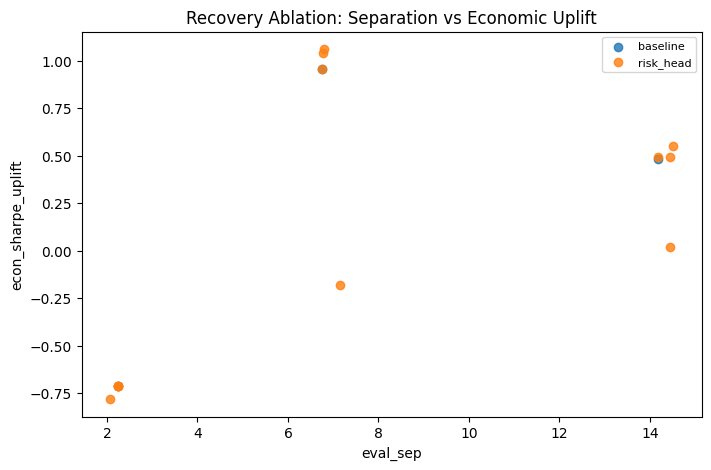

In [9]:
if not abl_df.empty and {"eval_sep", "econ_sharpe_uplift", "ablation_family"}.issubset(abl_df.columns):
    plot_df = abl_df.copy()
    if "row_type" in plot_df.columns:
        plot_df = plot_df[plot_df["row_type"].fillna("aggregate") != "fold"]

    plot_df["eval_sep"] = pd.to_numeric(plot_df["eval_sep"], errors="coerce")
    plot_df["econ_sharpe_uplift"] = pd.to_numeric(plot_df["econ_sharpe_uplift"], errors="coerce")
    plot_df = plot_df.dropna(subset=["eval_sep", "econ_sharpe_uplift"])

    fig, ax = plt.subplots(figsize=(8, 5))
    for family, g in plot_df.groupby("ablation_family"):
        ax.scatter(g["eval_sep"], g["econ_sharpe_uplift"], label=family, alpha=0.8)

    ax.set_xlabel("eval_sep")
    ax.set_ylabel("econ_sharpe_uplift")
    ax.set_title("Recovery Ablation: Separation vs Economic Uplift")
    ax.legend(loc="best", fontsize=8)
    plt.show()
else:
    print("Not enough columns/rows for plot yet.")
